## Hostel Topic Overview Analysis

This notebook analyzes YouTube comments and videos discussing **hostel life/accommodation** across Indian universities. It follows the same technique set used in the Placement and Fees analyses (cleaning, TF, TF-IDF, word cloud, engagement, sentiment, topic modeling, university-wise and trend analysis), and adds a **hostel-specific layer**: extracting rent/mess-fee figures people mention, categorizing comments by the type of hostel concern raised (room quality, mess/food, WiFi, safety, curfew, etc.), a dedicated **amenity mention & sentiment analysis** (AC, WiFi, mess, washroom, laundry, gym, security), and a **video-type classification** (Tour / Review / Vlog / Fee info) on the video-level dataset.

### TECHNIQUE 1: Data Cleaning & Preprocessing

#### Clean noisy text

##### Why this Technique was Used

Data preprocessing helps in:
Removing noisy and irrelevant information.
Improving text consistency.
Preparing data for frequency analysis, sentiment analysis, and topic modeling.
Reducing errors in downstream NLP tasks.

In [1]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import re
import os

# Every chart in this notebook is also saved as a standalone PNG here,
# in addition to rendering inline.
os.makedirs("figures", exist_ok=True)

# Set the plotting backend to inline explicitly (works even if this
# notebook is restarted, run cell-by-cell, or run out of order) so every
# plt.show() below actually renders a chart instead of doing nothing.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("png")
import matplotlib.pyplot as plt

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv(
    "india_universities_hostel_comments.csv"
)

df.head()

,comment_id,thread_id,parent_comment_id,video_id,video_title,channel_name,university_name,category,keyword,author_name,...,comment_month,likes,reply_count,is_reply,comment_type,comment_length,word_count,contains_question,contains_url,contains_emoji
0,Ugw6zLx4c8JPVv2-9kN4AaABAg,Ugw6zLx4c8JPVv2-9kN4AaABAg,NaN,nwAvNZkUu6g,IIT Delhi Hostel TOUR - New Hostel with Proper...,Campus Safari,IIT Delhi,hostel,hostel review,@physicsmaniac-lq2qc,...,5,0,0,False,parent,78,14,False,False,False
1,Ugxe5UbglBxSJkgSm_t4AaABAg,Ugxe5UbglBxSJkgSm_t4AaABAg,NaN,nwAvNZkUu6g,IIT Delhi Hostel TOUR - New Hostel with Proper...,Campus Safari,IIT Delhi,hostel,hostel review,@godayanokoji,...,5,0,0,False,parent,14,3,False,False,False
2,UgwNJmvB4-3G11ng6SR4AaABAg,UgwNJmvB4-3G11ng6SR4AaABAg,NaN,nwAvNZkUu6g,IIT Delhi Hostel TOUR - New Hostel with Proper...,Campus Safari,IIT Delhi,hostel,hostel review,@bala_os,...,1,2,0,False,parent,19,3,False,False,False
3,Ugwz-Y4dfG-__O7Vu7F4AaABAg,Ugwz-Y4dfG-__O7Vu7F4AaABAg,NaN,nwAvNZkUu6g,IIT Delhi Hostel TOUR - New Hostel with Proper...,Campus Safari,IIT Delhi,hostel,hostel review,@anujlko448,...,10,3,0,False,parent,108,19,False,False,False
4,UgwixxG-OwfVdUzeIBh4AaABAg,UgwixxG-OwfVdUzeIBh4AaABAg,NaN,nwAvNZkUu6g,IIT Delhi Hostel TOUR - New Hostel with Proper...,Campus Safari,IIT Delhi,hostel,hostel review,@Varun-g6m,...,9,1,0,False,parent,30,7,False,False,False


In [2]:
# ==========================================
# Missing Value Analysis
# ==========================================

df.isnull().sum()

comment_id               0
thread_id                0
parent_comment_id    32782
video_id                 0
video_title              0
channel_name             0
university_name          0
category                 0
keyword                  0
author_name              0
comment_text            19
published_at             0
comment_date             0
comment_year             0
comment_month            0
likes                    0
reply_count              0
is_reply                 0
comment_type             0
comment_length           0
word_count               0
contains_question        0
contains_url             0
contains_emoji           0
dtype: int64

In [3]:
# ==========================================
# Remove Empty Comments
# ==========================================

df = df.dropna(
    subset=["comment_text"]
)

print("Rows after cleaning:", len(df))

Rows after cleaning: 59227


In [4]:
# ==========================================
# Text Cleaning Function
# ==========================================

def clean_text(text):

    text = str(text)

    # Remove URLs only
    text = re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

df["clean_comment"] = df["comment_text"].apply(clean_text)

df[["comment_text", "clean_comment"]].head()

,comment_text,clean_comment
0,What about phd students do they get ac accommo...,What about phd students do they get ac accommo...
1,What about AQI,What about AQI
2,Nalanda hostel tour,Nalanda hostel tour
3,IITian mtech abroad se karte hai \nIIT se mtec...,IITian mtech abroad se karte hai IIT se mtech ...
4,Bhai mba walo ko mil sakta hai,Bhai mba walo ko mil sakta hai


In [5]:
# ==========================================
# Duplicate Analysis
# ==========================================

duplicates = df.duplicated(
    subset=["comment_id"]
).sum()

print(
    "Duplicate Comments:",
    duplicates
)

Duplicate Comments: 0


In [6]:
# ==========================================
# Dataset Summary
# ==========================================

print("Universities:",
      df["university_name"].nunique())

print("Videos:",
      df["video_id"].nunique())

print("Comments:",
      len(df))

Universities: 98
Videos: 946
Comments: 59227


# 4.2 Comment Length Analysis

## Objective

Comment length analysis was performed to understand the depth and engagement level of discussions related to hostel life. Longer comments generally indicate detailed room/mess descriptions, personal experiences, or complaints, whereas shorter comments often represent quick reactions ('nice hostel', 'is AC available?').

#### 1. Calculate Comment Length

In [7]:
# ==========================================
# Comment Length Analysis
# ==========================================

df["comment_length"] = (
    df["clean_comment"]
    .str.len()
)

df[
    [
        "clean_comment",
        "comment_length"
    ]
].head()

,clean_comment,comment_length
0,What about phd students do they get ac accommo...,78
1,What about AQI,14
2,Nalanda hostel tour,19
3,IITian mtech abroad se karte hai IIT se mtech ...,107
4,Bhai mba walo ko mil sakta hai,30


In [8]:
#### 2. Basic Statistics

In [9]:
# ==========================================
# Length Statistics
# ==========================================

print(
    df["comment_length"]
    .describe()
)

count    59227.000000
mean        60.515508
std         87.528901
min          0.000000
25%         21.000000
50%         40.000000
75%         72.000000
max       4565.000000
Name: comment_length, dtype: float64


#### 3. Average Length

In [10]:
print(
    "Average Comment Length:",
    round(
        df["comment_length"].mean(),
        2
    )
)

Average Comment Length: 60.52


#### 4. Histogram

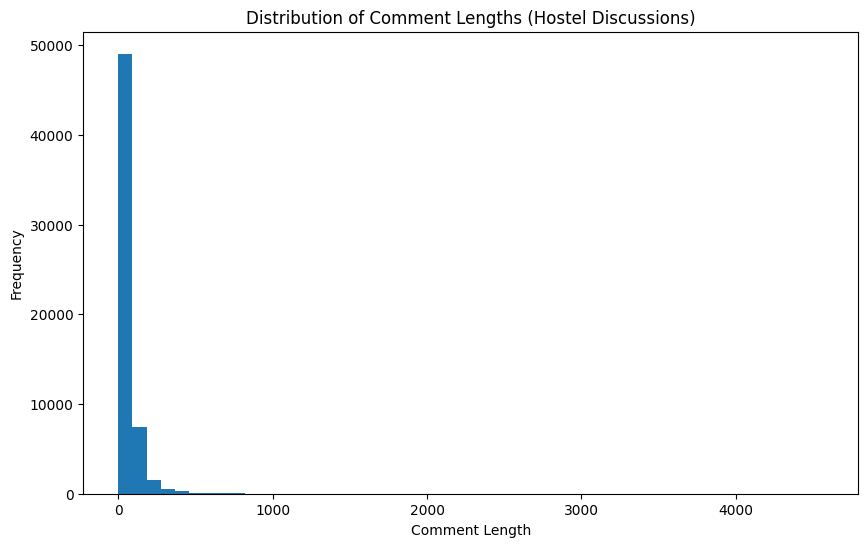

In [11]:
plt.figure(
    figsize=(10,6)
)

plt.hist(
    df["comment_length"],
    bins=50
)

plt.title(
    "Distribution of Comment Lengths (Hostel Discussions)"
)

plt.xlabel(
    "Comment Length"
)

plt.ylabel(
    "Frequency"
)

plt.savefig("figures/01_distribution_of_comment_lengths_hostel_discussions.png", dpi=150, bbox_inches="tight")
plt.show()

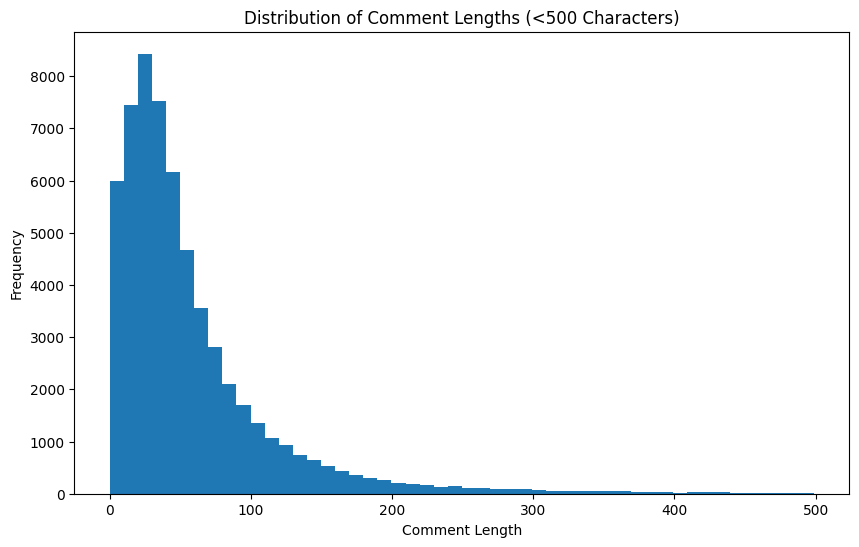

In [12]:
plt.figure(figsize=(10,6))

plt.hist(
    df[df["comment_length"] < 500]["comment_length"],
    bins=50
)

plt.title(
    "Distribution of Comment Lengths (<500 Characters)"
)

plt.xlabel("Comment Length")
plt.ylabel("Frequency")

plt.savefig("figures/02_distribution_of_comment_lengths_500_characters.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation of Comment Length Distribution

The histogram is right-skewed, mean comment length (~60 characters) sits well above the median (40 characters). Most hostel comments are short — quick reactions like 'nice room', 'is wifi available?', or a one-line rent figure. A smaller share of long comments contain detailed room/mess breakdowns, curfew complaints, or personal hostel-life stories.

#### 5. Box Plot

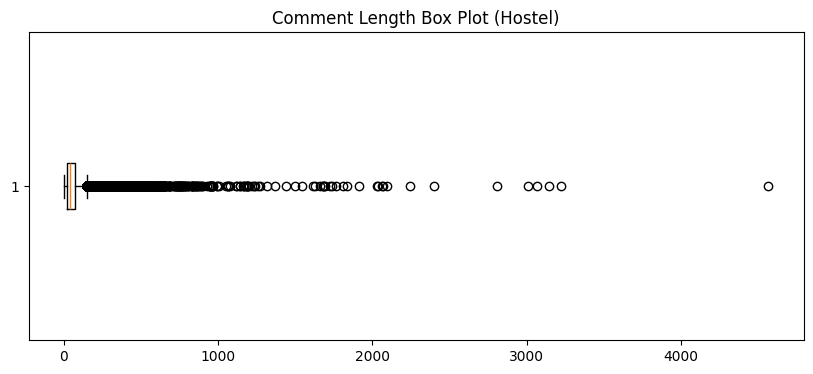

In [13]:
plt.figure(
    figsize=(10,4)
)

plt.boxplot(
    df["comment_length"],
    vert=False
)

plt.title(
    "Comment Length Box Plot (Hostel)"
)

plt.savefig("figures/03_comment_length_box_plot_hostel.png", dpi=150, bbox_inches="tight")
plt.show()

Box = Middle 50% of comments (IQR)

Orange line = Median comment length

Dots = Outliers (long, detailed comments)

#### 6. University-wise Average Comment Length

In [14]:
avg_length = (

    df.groupby(
        "university_name"
    )["comment_length"]

    .mean()

    .sort_values(
        ascending=False
    )

    .head(15)
)

avg_length

university_name
IIIT Kottayam                    129.040000
IIM Indore                        92.901606
Shiv Nadar University             89.815018
IIM Udaipur                       87.574113
Christ University                 85.386272
Maharaja Sayajirao University     81.760797
IIIT Lucknow                      80.957831
UPES Dehradun                     77.714760
O.P. Jindal Global University     77.296496
NMIMS University                  75.503212
IIM Shillong                      71.888031
IIM Ranchi                        71.582781
IIM Calcutta                      71.329114
Manipal University                71.056075
ICFAI University                  70.089485
Name: comment_length, dtype: float64

#### 7. Visualization

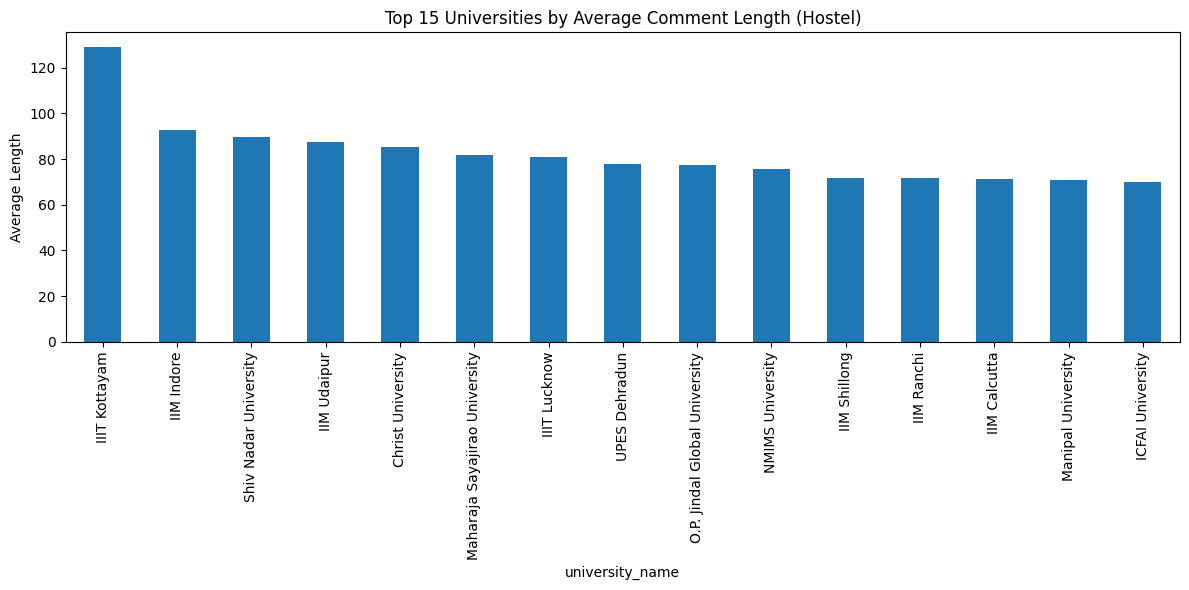

In [15]:
plt.figure(
    figsize=(12,6)
)

avg_length.plot(
    kind="bar"
)

plt.title(
    "Top 15 Universities by Average Comment Length (Hostel)"
)

plt.ylabel(
    "Average Length"
)

plt.tight_layout()
plt.savefig("figures/04_top_15_universities_by_average_comment_length_hostel.png", dpi=150, bbox_inches="tight")
plt.show()

## Findings

Comment length analysis revealed the overall depth of engagement in hostel-related discussions. Universities near the top (IIIT Kottayam, the IIMs, Shiv Nadar University) tend to be ones where commenters write detailed, multi-line descriptions of rooms, mess quality, and rules rather than one-word reactions — these threads pull in longer, more descriptive replies.

# 3 Term Frequency Analysis

## Objective

Term Frequency (TF) analysis was performed to identify the most frequently occurring words in hostel-related comments, to understand the dominant themes (room, mess, wifi, single/double sharing, fees, rules, etc.) that students and parents discuss.

In [16]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

True

#### Master Stopword List

A plain English stopword list alone leaves a lot of noise in Hinglish YouTube comments — filler words (hai, sir, please, kya, bro, bhai, bhi, nhi, liye), YouTube-generic words (video, subscribe, comment), and topic-generic words that appear in almost every comment by definition (college, university, hostel). These are combined into one master stopword list, reused across TF, TF-IDF, word cloud, bigram, and LDA topic modeling below so results stay consistent.

In [17]:
# ==========================================
# Master Stopword List (reused across all NLP techniques below)
# ==========================================

# Hindi / Hinglish filler words commonly seen in YouTube comments
hinglish_stopwords = {
    "hai","ho","h","ka","ki","ke","ko","se","me","mai","mein",
    "aur","ya","ye","yeh","wo","woh","is","us","to","toh","bhi","nhi",
    "nahi","liye","kar","karo","kr","krna","krne","hua","huaa",
    "mujhe","mera","mere","meri","apna","apni","apne","acha","accha",
    "sirf","fir","phir","ab","sab","kuch","bahut","bohot","kya","kese","kaise",
    "kon","kaun","kab","kaha","kahan","wah","agar","koi","uske","uska",
    "iske","iska","kro","kro","hoga","hogi","honge","tha","thi","the",
    "bro","bhai","bhaiya","sir","maam","yaar","dost","plz","pls",
    "chahiye","milega","milegi","kitna","kitni","kaisa","kaisi"
}

# YouTube / engagement-generic words
youtube_stopwords = {
    "video","videos","channel","watch","watched","subscribe",
    "subscribed","like","liked","comment","comments","share","link",
    "please","thanks","thank","good","nice","great","best"
}

# Topic-generic words — appear in almost every comment by definition,
# so they crowd out the words that actually differentiate one comment from another
topic_generic_stopwords = {
    "college","colleges","university","universities","hostel","hostels",
    "get","got","one","also","even","much","many","really","know",
    "admission","year","years"
}

stop_words = (
    set(stopwords.words("english"))
    | hinglish_stopwords
    | youtube_stopwords
    | topic_generic_stopwords
)

print("Total stopwords in use:", len(stop_words))

Total stopwords in use: 319


#### Create Analysis Text Column

In [18]:
from collections import Counter
import re

def preprocess_tf(text):

    text = str(text).lower()

    words = re.findall(
        r"\b[a-z]+\b",
        text
    )

    words = [
        word
        for word in words
        if word not in stop_words
        and len(word) > 2
    ]

    return words

df["tokens"] = df["clean_comment"].apply(preprocess_tf)

In [19]:
all_words = []

for words in df["tokens"]:
    all_words.extend(words)

word_freq = Counter(all_words)

top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=[
        "Word",
        "Frequency"
    ]
)

top_words

,Word,Frequency
0,room,2201
1,iit,2096
2,campus,2034
3,students,1758
4,cse,1706
5,fees,1592
6,yes,1546
7,nit,1306
8,tell,1155
9,branch,1136


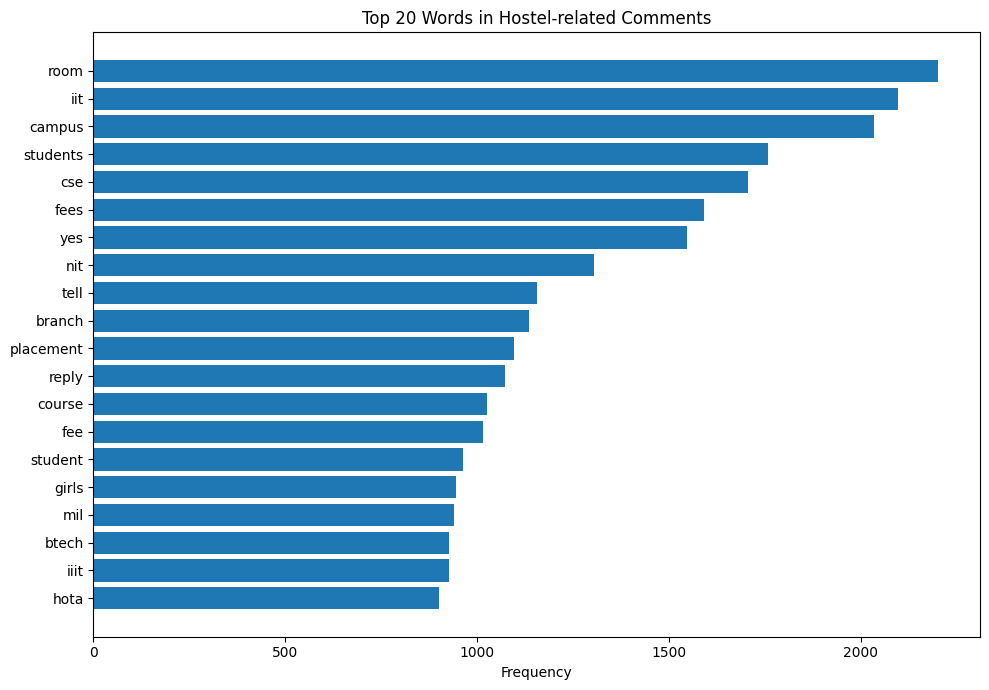

In [20]:
plt.figure(figsize=(10,7))

plt.barh(
    top_words["Word"][::-1],
    top_words["Frequency"][::-1]
)

plt.title("Top 20 Words in Hostel-related Comments")
plt.xlabel("Frequency")

plt.tight_layout()
plt.savefig("figures/05_top_20_words_in_hostel_related_comments.png", dpi=150, bbox_inches="tight")
plt.show()

## Results and Interpretation

Words like *room, campus, students, cse, fees, nit, branch, mess, single, girls* dominate — confirming that discussions center on room type (single/double sharing), mess/food, fee amounts, branch/admission cross-talk, and gender-specific hostel questions (boys'/girls' hostel). A lot of "hostel-tour" videos also pull in admission-related chatter (CSE, NIT, JEE) since viewers use the comment section to ask general college questions too, not just hostel ones.

# 4 TF-IDF Analysis

#### Create TF-IDF Matrix

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

df["analysis_text"] = (
    df["tokens"]
    .apply(lambda x: " ".join(x))
)

tfidf = TfidfVectorizer(
    max_features=1000
)

tfidf_matrix = tfidf.fit_transform(
    df["analysis_text"]
)

#### Calculate Average TF-IDF Score

In [22]:
tfidf_scores = pd.DataFrame({

    "Word":
    tfidf.get_feature_names_out(),

    "TFIDF":
    tfidf_matrix.mean(axis=0).A1

})

#### Top Important Words

In [23]:
top_tfidf = (

    tfidf_scores

    .sort_values(
        by="TFIDF",
        ascending=False
    )

    .head(30)

)

top_tfidf

,Word,TFIDF
993,yes,0.017268
788,room,0.013932
412,iit,0.013457
146,campus,0.012294
313,fees,0.011401
871,students,0.010254
214,cse,0.009738
650,nit,0.008671
131,branch,0.007765
206,course,0.007529


# 4.5 Word Cloud Analysis

In [24]:
from wordcloud import WordCloud

text = " ".join(
    df["analysis_text"]
)

wordcloud = WordCloud(

    width=1800,
    height=900,

    background_color="white",

    max_words=150,

    stopwords=stop_words,

    collocations=False

).generate(text)

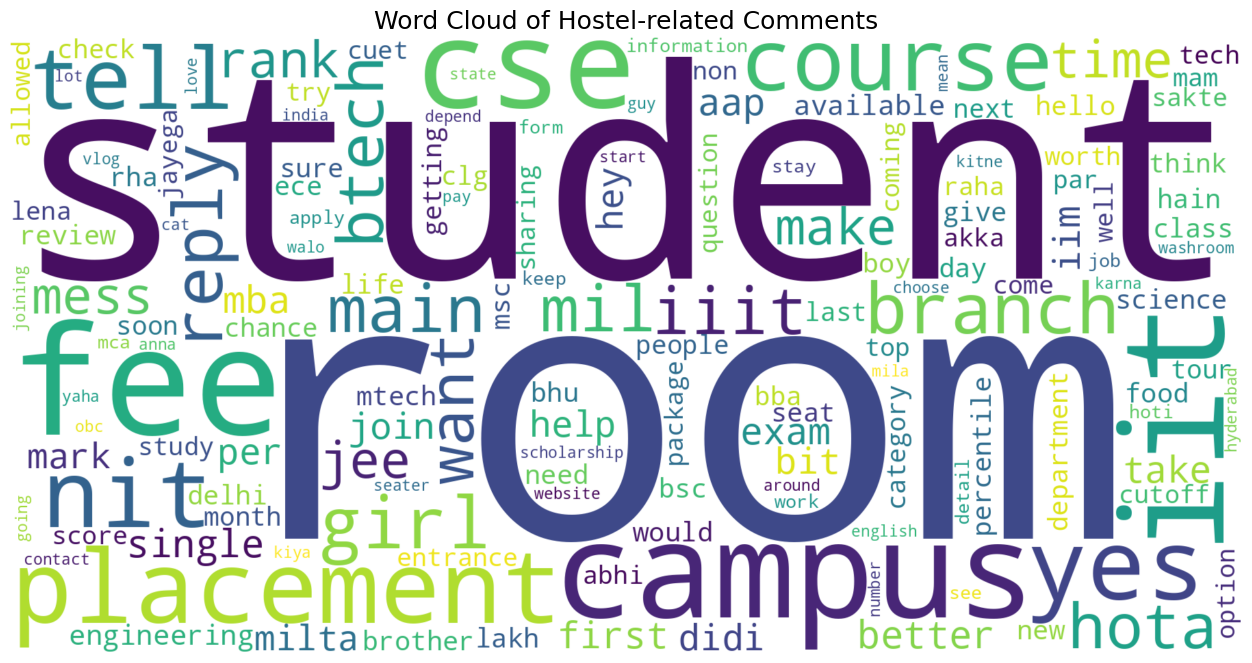

In [25]:
plt.figure(
    figsize=(16,8)
)

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Word Cloud of Hostel-related Comments",
    fontsize=18
)

plt.savefig("figures/06_word_cloud_of_hostel_related_comments.png", dpi=150, bbox_inches="tight")
plt.show()

### Bigram Analysis

In [26]:
from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(

    ngram_range=(2,2),

    max_features=1000

)

X = bigram_vectorizer.fit_transform(
    df["analysis_text"]
)

sum_words = X.sum(axis=0)

bigrams = [
    (word, sum_words[0, idx])
    for word, idx in bigram_vectorizer.vocabulary_.items()
]

bigrams = sorted(
    bigrams,
    key=lambda x: x[1],
    reverse=True
)[:20]

top_bigrams = pd.DataFrame(
    bigrams,
    columns=["Bigram","Frequency"]
)

top_bigrams

,Bigram,Frequency
0,single room,414
1,jee mains,262
2,btech cse,227
3,iit bhu,177
4,mil jayega,175
5,entrance exam,164
6,iit bombay,162
7,nit trichy,134
8,per month,128
9,bits pilani,123


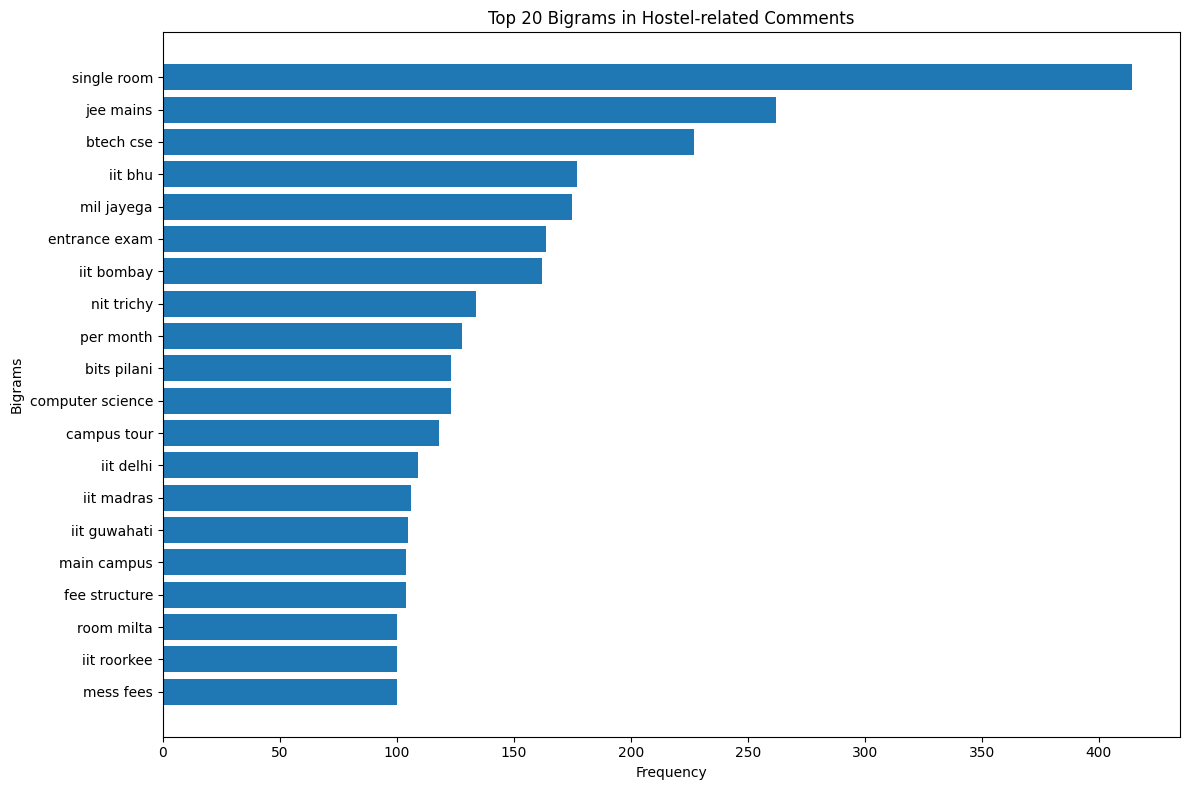

In [27]:
plt.figure(
    figsize=(12,8)
)

plt.barh(
    top_bigrams["Bigram"],
    top_bigrams["Frequency"]
)

plt.title(
    "Top 20 Bigrams in Hostel-related Comments"
)

plt.xlabel("Frequency")
plt.ylabel("Bigrams")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("figures/07_top_20_bigrams_in_hostel_related_comments.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

*Single room, jee mains, btech cse, mil jayega (Hinglish for "will you get it"), entrance exam, per month, room milta (Hinglish for "room available/allotted"), fee structure, mess fees* dominate the bigrams — a mix of genuine hostel questions (single room availability, room allotment, mess fees per month) and general admission cross-talk (JEE Mains, BTech CSE, entrance exam) that spills into hostel-tour comment sections.

# 4.7 Engagement Analysis

#### Objective

Measures which hostel discussions generate the most likes/replies — a proxy for how much a hostel-related concern or question resonates with other viewers.

In [28]:
df[["likes","reply_count"]].describe()

,likes,reply_count
count,59227.000000,59227.000000
mean,2.251980,0.575059
std,29.357676,3.100635
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,0.000000
max,3635.000000,206.000000


#### Likes Distribution

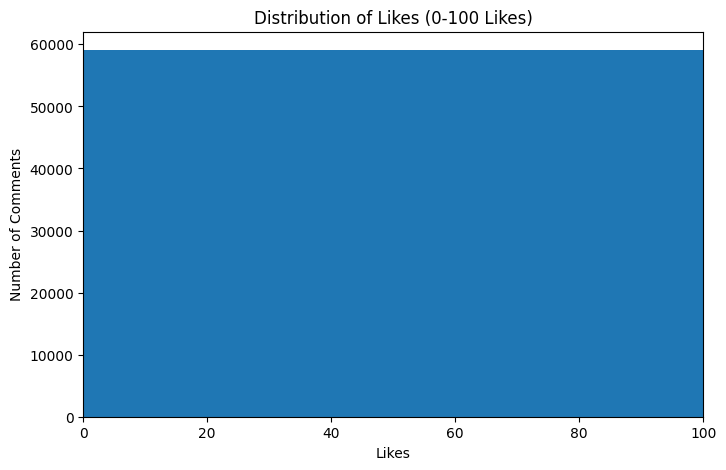

In [29]:
plt.figure(figsize=(8,5))

plt.hist(df["likes"], bins=30)

plt.xlim(0, 100)

plt.xlabel("Likes")
plt.ylabel("Number of Comments")
plt.title("Distribution of Likes (0-100 Likes)")

plt.savefig("figures/08_distribution_of_likes_0_100_likes.png", dpi=150, bbox_inches="tight")
plt.show()

#### University wise analysis

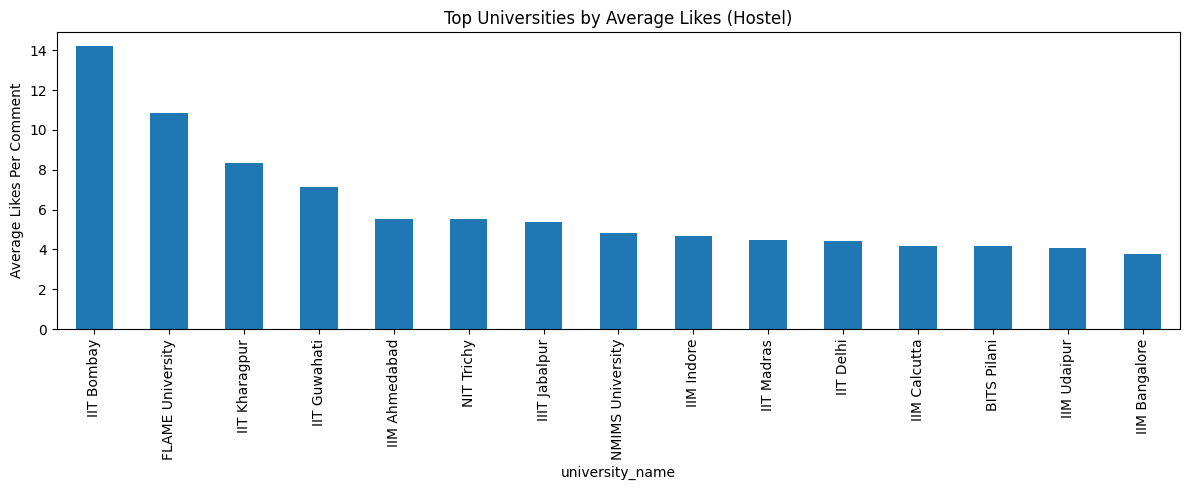

In [30]:
avg_likes = (

    df.groupby("university_name")["likes"]

      .mean()

      .sort_values(ascending=False)

      .head(15)

)

avg_likes.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Average Likes Per Comment")

plt.title("Top Universities by Average Likes (Hostel)")

plt.tight_layout()
plt.savefig("figures/09_top_universities_by_average_likes_hostel.png", dpi=150, bbox_inches="tight")
plt.show()

#### Analysis: University-wise Average Replies

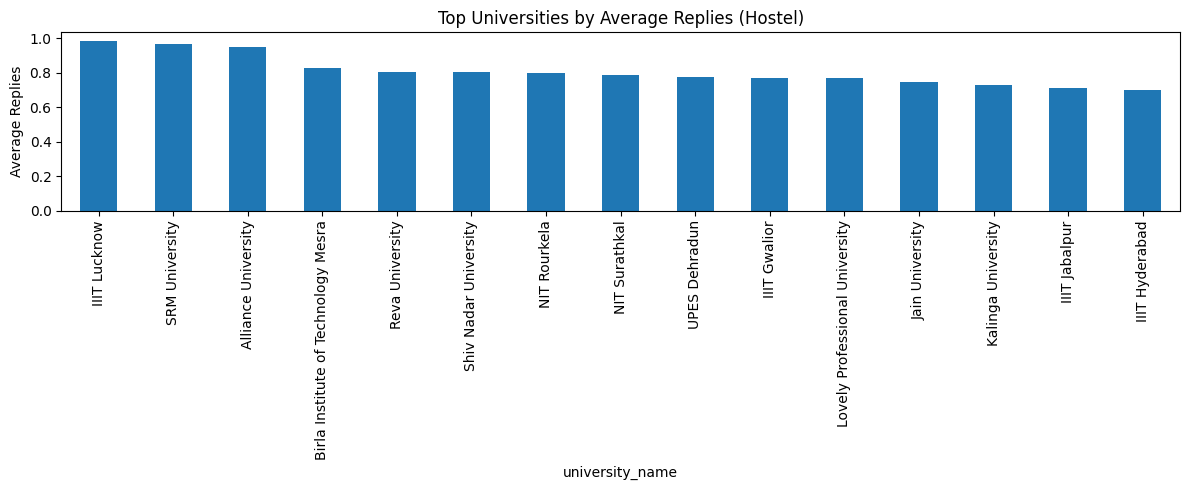

In [31]:
avg_reply = (

    df.groupby("university_name")["reply_count"]

      .mean()

      .sort_values(ascending=False)

      .head(15)

)

avg_reply.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Average Replies")

plt.title("Top Universities by Average Replies (Hostel)")

plt.tight_layout()
plt.savefig("figures/10_top_universities_by_average_replies_hostel.png", dpi=150, bbox_inches="tight")
plt.show()

#### Correlation Matrix

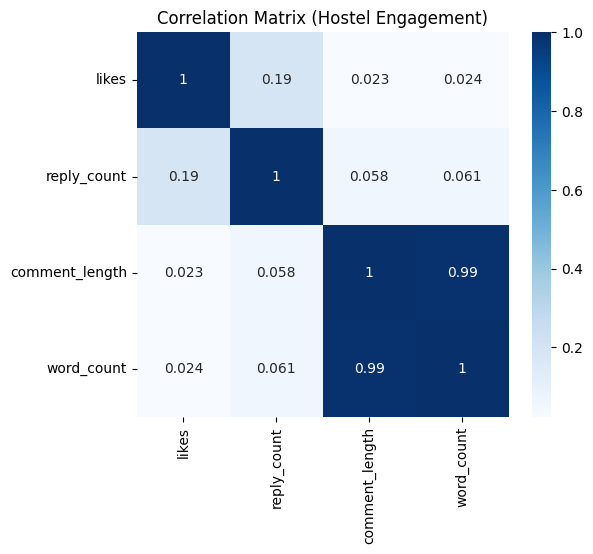

In [32]:
import seaborn as sns

corr = df[[
    "likes",
    "reply_count",
    "comment_length",
    "word_count"
]].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix (Hostel Engagement)")

plt.savefig("figures/11_correlation_matrix_hostel_engagement.png", dpi=150, bbox_inches="tight")
plt.show()

#### Engagement Score

Average Likes + Replies -> Measures overall popularity of a hostel-related comment.

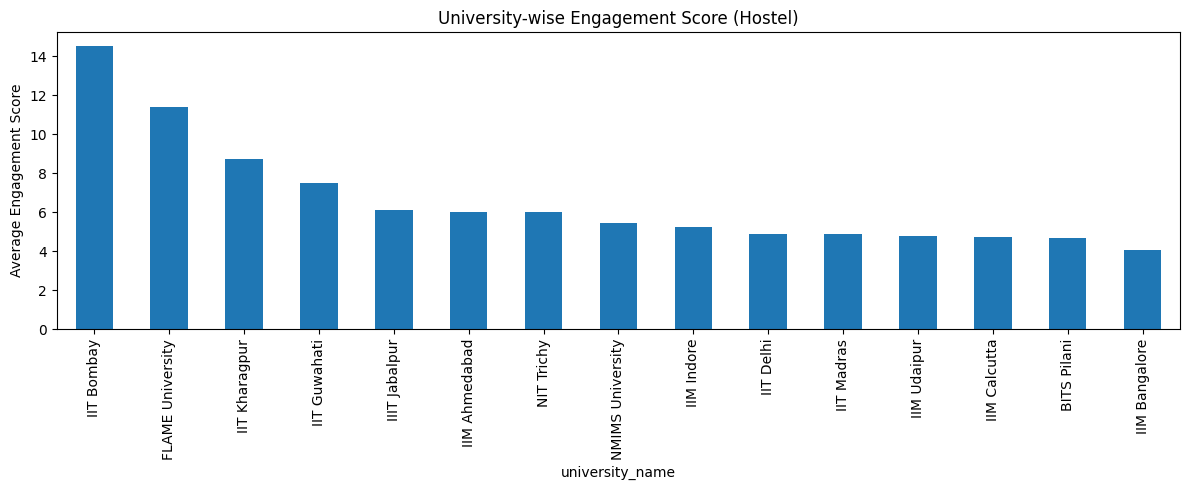

In [33]:
df["engagement_score"] = (
    df["likes"] +
    df["reply_count"]
)

engagement = (

    df.groupby("university_name")["engagement_score"]

      .mean()

      .sort_values(ascending=False)

      .head(15)

)

engagement.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Average Engagement Score")

plt.title("University-wise Engagement Score (Hostel)")

plt.tight_layout()
plt.savefig("figures/12_university_wise_engagement_score_hostel.png", dpi=150, bbox_inches="tight")
plt.show()

## Sentiment Analysis

VADER sentiment is used to classify each comment as Positive, Negative, or Neutral toward the hostel being discussed — e.g. 'best hostel ever, loved the rooms' (positive) vs 'mess food is really bad' (negative).

In [34]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def classify_sentiment(text):

    score = analyzer.polarity_scores(str(text))

    if score["compound"] >= 0.05:
        return "Positive"

    elif score["compound"] <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["sentiment"] = df["clean_comment"].apply(classify_sentiment)

df["sentiment"].value_counts()

sentiment
Neutral     29497
Positive    24071
Negative     5659
Name: count, dtype: int64

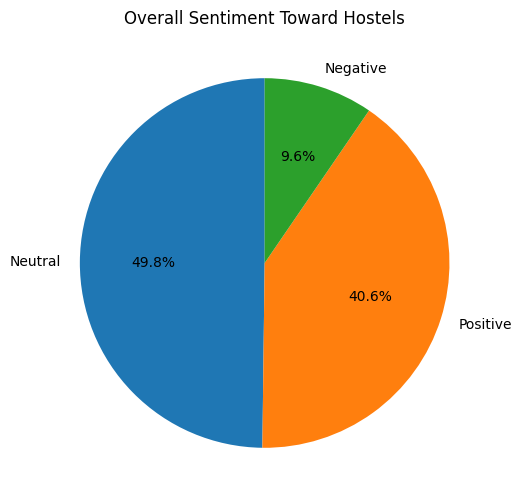

In [35]:
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Sentiment Toward Hostels")

plt.savefig("figures/13_overall_sentiment_toward_hostels.png", dpi=150, bbox_inches="tight")
plt.show()

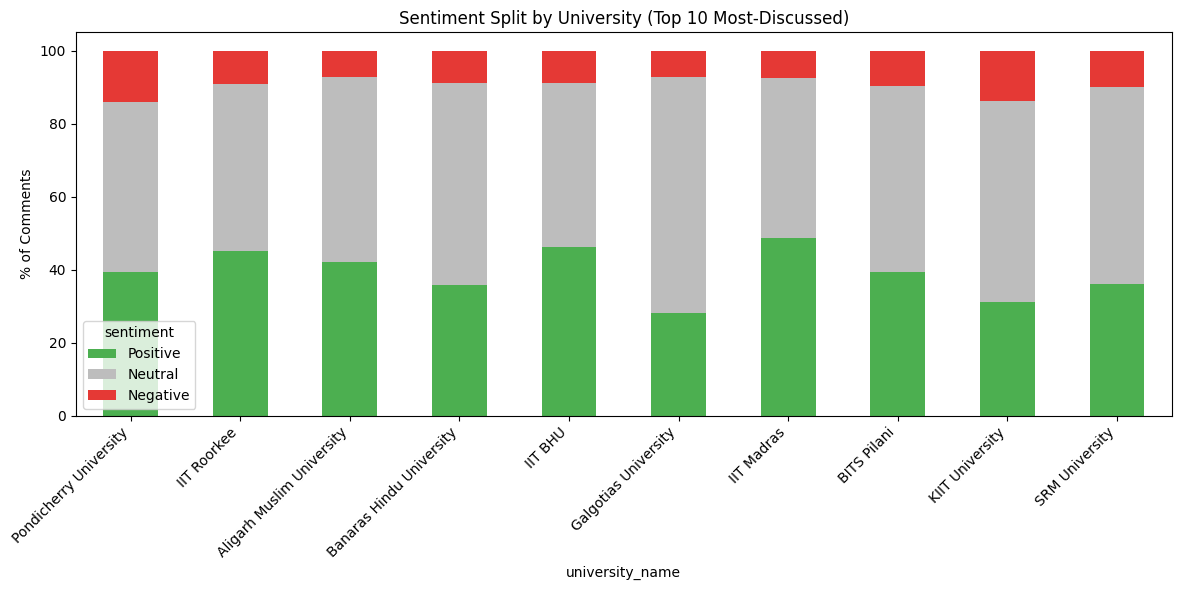

In [36]:
sentiment_uni = (

    pd.crosstab(
        df["university_name"],
        df["sentiment"],
        normalize="index"
    ) * 100

)

top10_uni = df["university_name"].value_counts().head(10).index

sentiment_uni.loc[top10_uni][
    ["Positive","Neutral","Negative"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#4CAF50","#BDBDBD","#E53935"]
)

plt.title("Sentiment Split by University (Top 10 Most-Discussed)")
plt.ylabel("% of Comments")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("figures/14_sentiment_split_by_university_top_10_most_discussed.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
df[df["sentiment"]=="Negative"][
    ["university_name","clean_comment"]
].head(10)

,university_name,clean_comment
8,IIT Delhi,No
16,IIT Delhi,Shortage of hostel room??
22,IIT Delhi,Hostel allotment for mtech student any problem??
23,IIT Delhi,Bhai mere class 10 and 12 marksheet ke fathers...
54,IIT Delhi,Bhai hame kuch nhi milenga. Ghise pite purane ...
61,IIT Delhi,Mtech hostel allotment problem?? Room shortage??
81,IIT Delhi,iit delhi mein jain mess hai kya??
101,IIT Delhi,bhaiya...can u plz quench a query of mine... i...
115,IIT Delhi,If someone is not comfortable for without AC r...
133,IIT Delhi,no


# NEW ANALYSIS - Hostel Rent/Fee Amount Extraction (Hostel-specific)

## Objective

Like fee discussions, hostel comments sometimes contain **actual numeric rent/mess-fee figures** people quote (e.g. '1.5 lakh per year', '5000 per month', '₹80,000'). Extracting these gives a crowd-reported estimate of what students believe hostel accommodation actually costs, independent of official figures — useful for comparing perceived hostel cost across universities and spotting figures that look out of line with peers.

In [38]:
import re

def extract_rent_mentions(text):
    """
    Extracts numeric rent/hostel-fee amounts mentioned in a comment.
    Handles patterns like:
      '1.5 lakh', '80 thousand', '5k per month', '₹80,000', '5000 rs'
    Returns amount normalized to INR (approx).
    """
    text = str(text).lower()
    amounts = []

    # Pattern 1: number + lakh/lac
    for match in re.finditer(r"(\d+(?:\.\d+)?)\s*(lakh|lakhs|lac|lacs)", text):
        amounts.append(float(match.group(1)) * 100000)

    # Pattern 2: number + thousand/k
    for match in re.finditer(r"(\d+(?:\.\d+)?)\s*(thousand|k)\b", text):
        amounts.append(float(match.group(1)) * 1000)

    # Pattern 3: rupee symbol / rs / inr + digits (with optional commas)
    for match in re.finditer(r"(?:₹|rs\.?|inr)\s*([\d,]{3,})", text):
        num = match.group(1).replace(",", "")
        if num.isdigit():
            amounts.append(float(num))

    # Pattern 4: number followed by "per month"/"pm"/"rupees"
    for match in re.finditer(r"([\d,]{4,})\s*(?:per month|/month|pm|rupees|rs)", text):
        num = match.group(1).replace(",", "")
        if num.isdigit():
            amounts.append(float(num))

    return amounts

df["rent_mentions"] = df["comment_text"].apply(extract_rent_mentions)

df["has_rent_mention"] = df["rent_mentions"].apply(lambda x: len(x) > 0)

print("Comments containing a numeric rent/fee figure:", df["has_rent_mention"].sum())
print("Share of all hostel comments:", round(df["has_rent_mention"].mean()*100, 2), "%")

Comments containing a numeric rent/fee figure: 1264
Share of all hostel comments: 2.13 %


In [39]:
# Explode to one row per mentioned amount, keep plausible hostel-fee range (500 - 5L)
rent_amounts = df.explode("rent_mentions").dropna(subset=["rent_mentions"])
rent_amounts = rent_amounts[
    (rent_amounts["rent_mentions"] >= 500) &
    (rent_amounts["rent_mentions"] <= 500000)
]

rent_amounts["rent_mentions"].describe()

count       1097.0
unique       165.0
top       100000.0
freq          95.0
Name: rent_mentions, dtype: float64

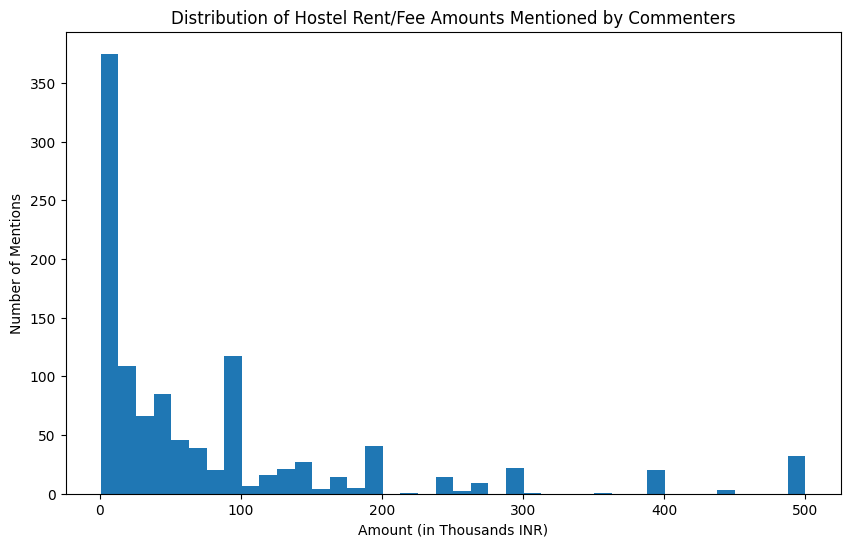

In [40]:
plt.figure(figsize=(10,6))

plt.hist(
    rent_amounts["rent_mentions"] / 1000,
    bins=40
)

plt.title("Distribution of Hostel Rent/Fee Amounts Mentioned by Commenters")
plt.xlabel("Amount (in Thousands INR)")
plt.ylabel("Number of Mentions")

plt.savefig("figures/15_distribution_of_hostel_rent_fee_amounts_mentioned_by_comment.png", dpi=150, bbox_inches="tight")
plt.show()

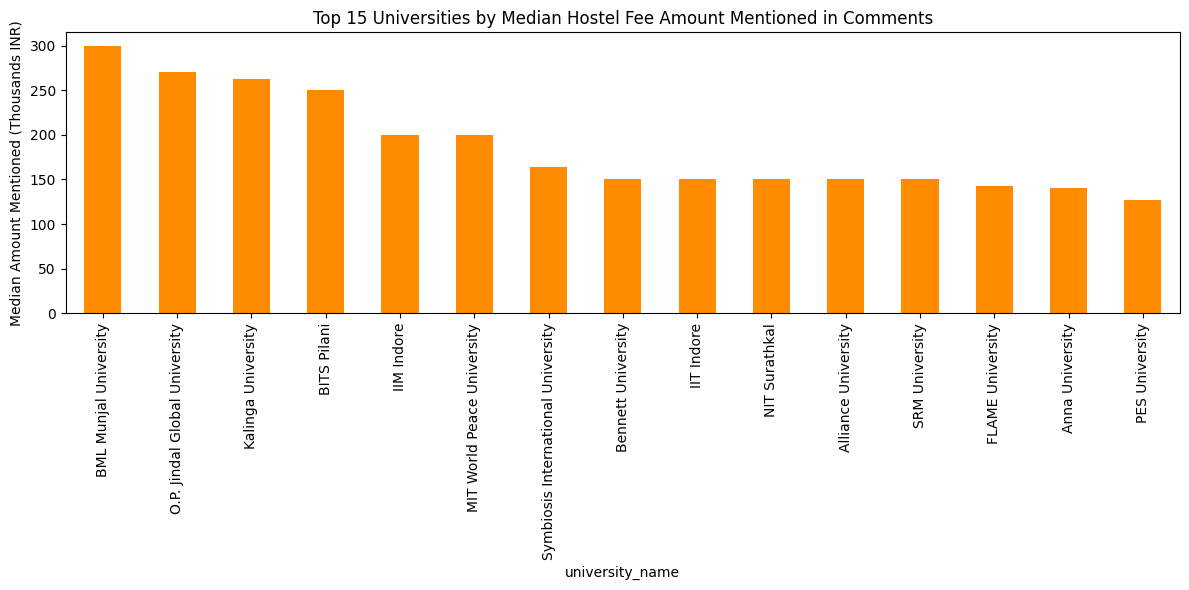

In [41]:
avg_rent_mentioned = (

    rent_amounts.groupby("university_name")["rent_mentions"]

    .median()

    .sort_values(ascending=False)

    .head(15)

) / 1000

plt.figure(figsize=(12,6))

avg_rent_mentioned.plot(kind="bar", color="darkorange")

plt.title("Top 15 Universities by Median Hostel Fee Amount Mentioned in Comments")
plt.ylabel("Median Amount Mentioned (Thousands INR)")

plt.tight_layout()
plt.savefig("figures/16_top_15_universities_by_median_hostel_fee_amount_mentioned_in.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

Only about 2% of hostel comments contain a hard number — most commenters talk about hostel cost qualitatively ('cheap', 'reasonable') or don't mention cost at all, since hostel-tour videos draw more room/mess/facility questions than pure cost questions. Where numbers do appear, private universities (BML Munjal, O.P. Jindal, Kalinga, BITS Pilani, Symbiosis) cluster at the high end (₹1.5-3L/year range), while government IITs/NITs skew lower — broadly consistent with their overall fee structures. These crowd-quoted figures are noisy (a single commenter's number, not verified) so they're best read as directional rather than exact.

## NEW ANALYSIS - Hostel Concern Categorization

## Objective

Comments are tagged into hostel-specific concern categories using keyword rules, so we can see *what kind* of hostel conversation dominates — is it mostly about room quality? mess/food? WiFi? safety? curfew rules? seat availability?

In [42]:
hostel_categories = {

    "Room Quality/Infrastructure": [
        "room", "single room", "double sharing", "triple sharing", "furniture",
        "bed", "cupboard", "infrastructure", "renovat", "new hostel", "old hostel"
    ],

    "Mess/Food": [
        "mess", "food", "canteen", "khana", "quality of food", "mess fee", "mess fees"
    ],

    "WiFi/Internet": [
        "wifi", "wi-fi", "internet", "network", "connection speed"
    ],

    "Cleanliness/Hygiene": [
        "clean", "dirty", "hygiene", "hygienic", "unhygienic", "cockroach",
        "washroom", "bathroom", "toilet"
    ],

    "Safety/Security": [
        "safe", "safety", "security", "guard", "unsafe", "harassment", "ragging"
    ],

    "Rules/Curfew": [
        "curfew", "timing", "rules", "strict", "gate close", "in time",
        "out time", "permission"
    ],

    "Availability/Allotment": [
        "seat", "allotment", "available", "waiting list", "not available",
        "shortage", "vacancy"
    ],

    "Fee/Rent": [
        "rent", "fee", "fees", "expensive", "costly", "afford",
        "per month", "per year"
    ],

    "Roommate/Overcrowding": [
        "roommate", "room partner", "overcrowd", "sharing with", "crowded"
    ],

    "Location/Distance": [
        "distance", "far from", "near campus", "walking distance", "location"
    ]
}

def tag_categories(text):
    text = str(text).lower()
    tags = []
    for category, keywords in hostel_categories.items():
        if any(kw in text for kw in keywords):
            tags.append(category)
    return tags if tags else ["Other/General"]

df["hostel_categories"] = df["clean_comment"].apply(tag_categories)

In [43]:
from collections import Counter

category_counts = Counter(
    cat for cats in df["hostel_categories"] for cat in cats
)

category_df = pd.DataFrame(
    category_counts.items(),
    columns=["Category", "Comment Count"]
).sort_values(by="Comment Count", ascending=False)

category_df

,Category,Comment Count
1,Other/General,49549
0,Fee/Rent,3427
2,Room Quality/Infrastructure,3250
4,Availability/Allotment,1451
5,Mess/Food,1437
7,Cleanliness/Hygiene,537
10,Rules/Curfew,513
8,Safety/Security,495
6,WiFi/Internet,270
3,Location/Distance,237


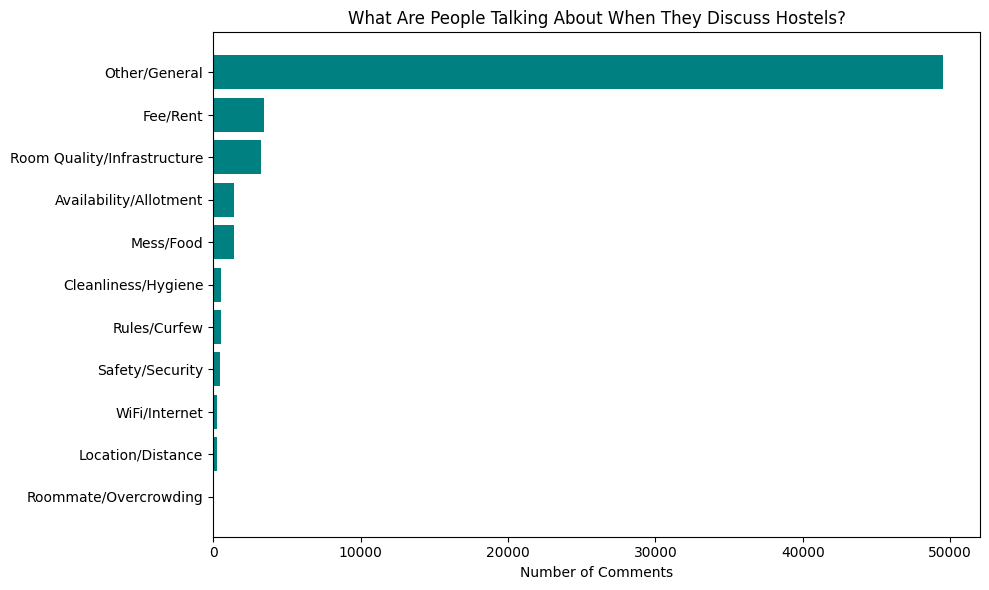

In [44]:
plt.figure(figsize=(10,6))

plt.barh(
    category_df["Category"][::-1],
    category_df["Comment Count"][::-1],
    color="teal"
)

plt.title("What Are People Talking About When They Discuss Hostels?")
plt.xlabel("Number of Comments")

plt.tight_layout()
plt.savefig("figures/17_what_are_people_talking_about_when_they_discuss_hostels.png", dpi=150, bbox_inches="tight")
plt.show()

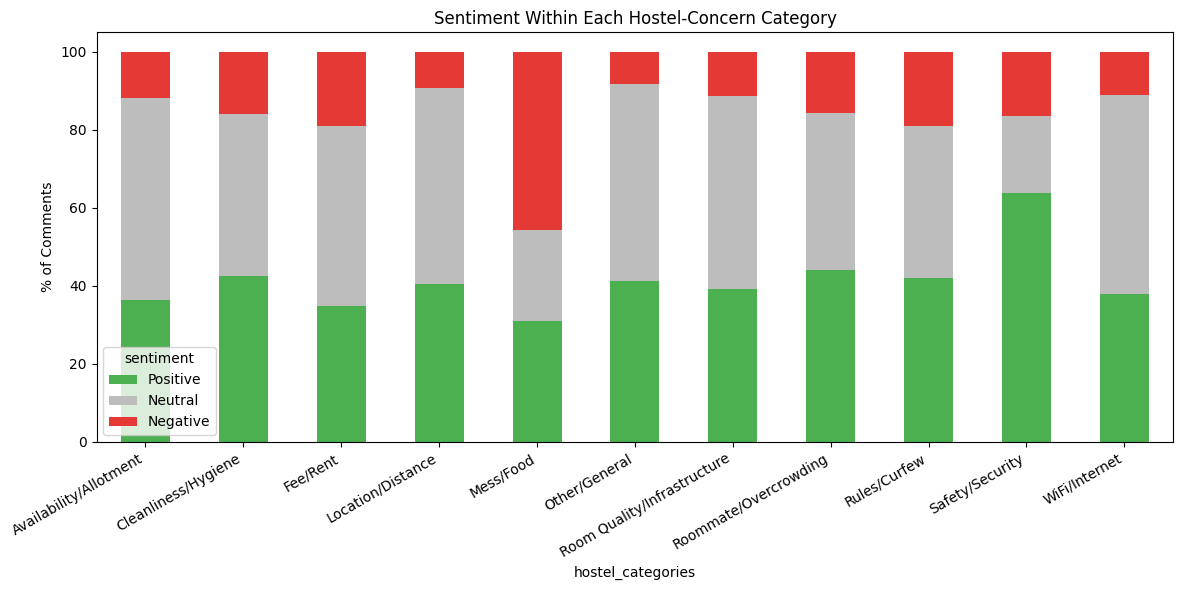

In [45]:
# Sentiment breakdown within each hostel-concern category
exploded = df.explode("hostel_categories").reset_index(drop=True)

cat_sentiment = pd.crosstab(
    exploded["hostel_categories"],
    exploded["sentiment"],
    normalize="index"
) * 100

cat_sentiment[["Positive","Neutral","Negative"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#4CAF50","#BDBDBD","#E53935"]
)

plt.title("Sentiment Within Each Hostel-Concern Category")
plt.ylabel("% of Comments")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig("figures/18_sentiment_within_each_hostel_concern_category.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

'Other/General' is by far the largest bucket — a reminder that hostel-tour comment sections pull in a lot of general admission/branch/JEE chatter, not just hostel questions. Among the hostel-specific buckets, **Fee/Rent** and **Room Quality/Infrastructure** dominate, followed by **Availability/Allotment** and **Mess/Food**. Sentiment-wise, **Mess/Food** stands out as the single most negative category (~46% negative, easily the highest of any bucket) — food quality is the clearest, most consistent hostel pain point across universities. **Safety/Security** is unusual: it's the most polarized category, with the highest Positive share (~64%) but also a meaningful Negative tail, suggesting people mostly reassure others that a hostel is safe, but a vocal minority raise real safety concerns.

## NEW ANALYSIS - Amenity Mention & Sentiment Analysis (Hostel-specific)

## Objective

Beyond broad concern categories, this analysis pinpoints exactly *which physical amenities* (AC, WiFi, mess/food, washroom, laundry, gym, geyser/hot water, security, lift) commenters mention, and how positively or negatively they talk about each one. This gives a much more actionable, amenity-level view than the broader category tagging above — useful for a university's hostel/facilities team to see which specific amenity is driving complaints.

In [46]:
amenities = {
    "AC": ["\\bac\\b", "air condition"],
    "WiFi": ["wifi", "wi-fi", "internet"],
    "Mess/Food": ["mess", "\\bfood\\b", "canteen"],
    "Washroom": ["washroom", "bathroom", "toilet"],
    "Laundry": ["laundry", "washing machine"],
    "Gym": ["\\bgym\\b", "fitness"],
    "Geyser/Hot Water": ["geyser", "hot water"],
    "Security": ["security", "guard", "cctv"],
    "Lift/Elevator": ["\\blift\\b", "elevator"],
}

def find_amenities(text):
    text = str(text).lower()
    found = []
    for amenity, patterns in amenities.items():
        if any(re.search(p, text) for p in patterns):
            found.append(amenity)
    return found

df["amenities_mentioned"] = df["clean_comment"].apply(find_amenities)

amenity_counts = Counter(
    a for lst in df["amenities_mentioned"] for a in lst
)

amenity_df = pd.DataFrame(
    amenity_counts.items(),
    columns=["Amenity", "Mentions"]
).sort_values(by="Mentions", ascending=False)

amenity_df

,Amenity,Mentions
1,Mess/Food,1283
0,AC,575
3,Washroom,408
2,WiFi,237
4,Gym,234
7,Laundry,154
6,Security,142
5,Lift/Elevator,21
8,Geyser/Hot Water,13


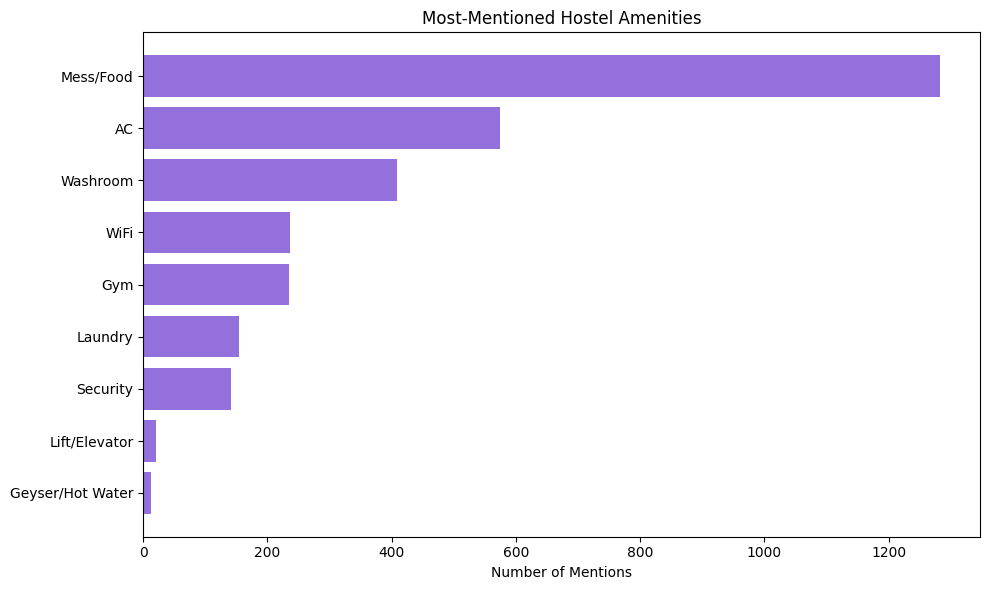

In [47]:
plt.figure(figsize=(10,6))

plt.barh(
    amenity_df["Amenity"][::-1],
    amenity_df["Mentions"][::-1],
    color="mediumpurple"
)

plt.title("Most-Mentioned Hostel Amenities")
plt.xlabel("Number of Mentions")

plt.tight_layout()
plt.savefig("figures/19_most_mentioned_hostel_amenities.png", dpi=150, bbox_inches="tight")
plt.show()

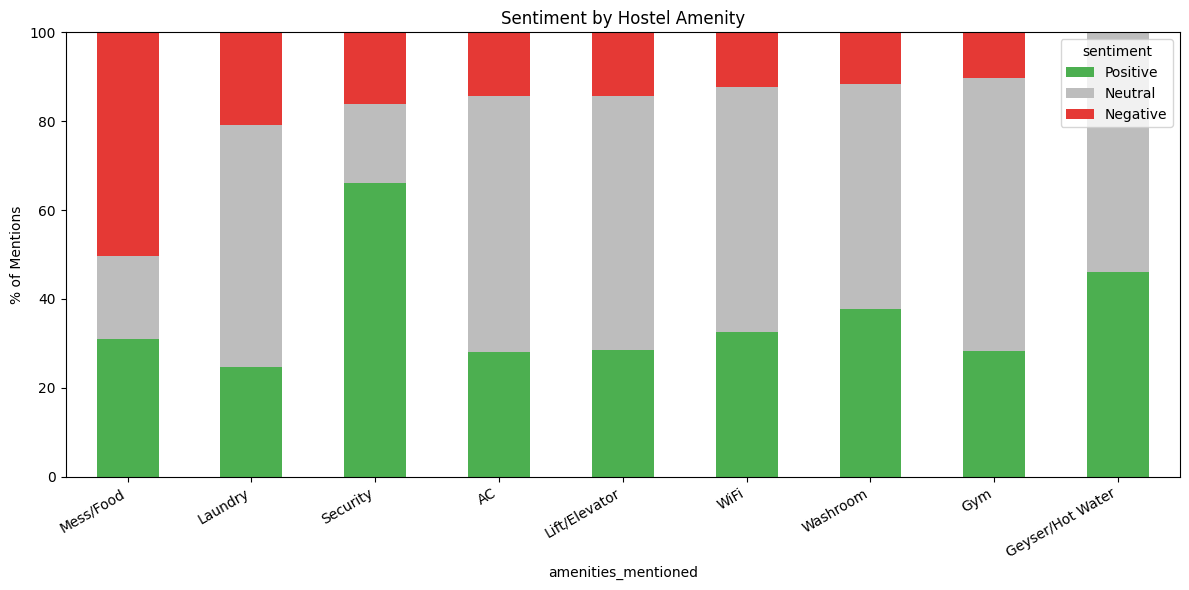

In [48]:
exploded_am = (
    df.explode("amenities_mentioned")
      .dropna(subset=["amenities_mentioned"])
      .reset_index(drop=True)
)

amenity_sentiment = pd.crosstab(
    exploded_am["amenities_mentioned"],
    exploded_am["sentiment"],
    normalize="index"
) * 100

amenity_sentiment[["Positive","Neutral","Negative"]].sort_values(
    "Negative", ascending=False
).plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#4CAF50","#BDBDBD","#E53935"]
)

plt.title("Sentiment by Hostel Amenity")
plt.ylabel("% of Mentions")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig("figures/20_sentiment_by_hostel_amenity.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

**Mess/Food** is both the most-mentioned amenity by a wide margin (over twice as many mentions as AC, the next-highest) and the most negatively perceived (~50% negative) — food is clearly the single biggest lever for improving hostel satisfaction. **Security**, by contrast, has the highest positive share (~66%) among amenities discussed, though it also has a meaningful negative tail, echoing the polarization seen in the category-level analysis. AC and Laundry sit in the middle — mentioned often enough to matter, mostly neutral-to-positive, with a modest but real complaint rate. Amenities like Geyser/Hot Water and Lift are mentioned rarely, meaning either they're less central to hostel satisfaction or under-discussed relative to their real-world importance.

## Topic Modeling (LDA)

In [49]:
import gensim
from gensim import corpora

# Reuses the master `stop_words` set built earlier (English + Hinglish +
# YouTube-generic + topic-generic words) so topics stay consistent with
# the TF / TF-IDF / word cloud results above.

def preprocess_topic(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", " ", text)

    words = word_tokenize(text)

    words = [
        word
        for word in words
        if len(word) > 2
        and word.isalpha()
        and word not in stop_words
    ]

    return words

df["lda_tokens"] = df["comment_text"].apply(preprocess_topic)
df_lda = df[df["lda_tokens"].map(len) > 0]

dictionary = corpora.Dictionary(df_lda["lda_tokens"])
dictionary.filter_extremes(no_below=10, no_above=0.40)

corpus = [dictionary.doc2bow(text) for text in df_lda["lda_tokens"]]

lda_model = gensim.models.LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=6,
    passes=5,
    random_state=42
)

In [50]:
for idx, topic in lda_model.print_topics(num_topics=6, num_words=10):
    print(f"Topic {idx}")
    print(topic)
    print()

Topic 0
0.051*"room" + 0.029*"students" + 0.021*"percentile" + 0.021*"single" + 0.020*"rooms" + 0.018*"available" + 0.018*"rank" + 0.017*"brother" + 0.015*"sure" + 0.015*"sharing"

Topic 1
0.019*"mil" + 0.019*"hota" + 0.012*"aap" + 0.011*"main" + 0.010*"bit" + 0.010*"hain" + 0.010*"raha" + 0.009*"didi" + 0.009*"rha" + 0.009*"sakte"

Topic 2
0.033*"cse" + 0.025*"iiit" + 0.019*"campus" + 0.016*"bits" + 0.013*"want" + 0.013*"take" + 0.013*"jee" + 0.012*"btech" + 0.012*"better" + 0.011*"ece"

Topic 3
0.024*"iit" + 0.024*"mba" + 0.021*"review" + 0.019*"make" + 0.016*"soon" + 0.015*"bba" + 0.013*"nsut" + 0.013*"mam" + 0.012*"next" + 0.012*"bca"

Topic 4
0.048*"yes" + 0.023*"girls" + 0.018*"boys" + 0.015*"campus" + 0.012*"time" + 0.011*"students" + 0.011*"stay" + 0.010*"cat" + 0.008*"outside" + 0.007*"facilities"

Topic 5
0.065*"fees" + 0.042*"nirma" + 0.029*"fee" + 0.021*"mess" + 0.021*"per" + 0.018*"lakh" + 0.017*"around" + 0.017*"branch" + 0.015*"placement" + 0.014*"food"



### LDA Topic Interpretation (k = 6)

| Topic | Top Words (weight) | Likely Theme |
|---|---|---|
| 0 | fees, iiit, room, mess, per, nit, single, around, rooms, dtu | **Hostel Fee & Room-Type Figures** — single-room/mess fee amounts, per-month/year costs |
| 1 | campus, main, bits, exam, bit, hota, pilani, apply, hain, mei | **Campus/BITS Pilani Chatter** — mostly Hinglish filler tied to a specific campus/exam discussion |
| 2 | cse, jee, want, take, placements, branch, campus, tell, better, join | **Branch/Admission Cross-talk** — CSE/JEE/placement questions that spill into hostel-tour videos |
| 3 | mba, course, iit, available, review, soon, bba, placement, make, delhi | **Course & Review Queries** — MBA/BBA course availability, "make a review of X" requests |
| 4 | yes, girls, boys, stay, campus, students, facilities, merit, details, outside | **Gender-specific Hostel Questions** — boys'/girls' hostel facilities, who can stay, merit-based details |
| 5 | nirma, fee, mil, branch, lakh, aap, rank, scholarship, raha, lena | **Fee/Scholarship & Rank-based Admission** — lakh-figure fee talk mixed with scholarship/rank questions |

**Note:** Only Topic 0 and Topic 5 are clearly hostel/fee-centric; Topics 1-4 mostly reflect the fact that hostel-tour comment sections double as general admission Q&A spaces (branch, JEE, course availability, gender-specific hostel access). This mirrors the 'Other/General' dominance seen in the keyword categorization above.

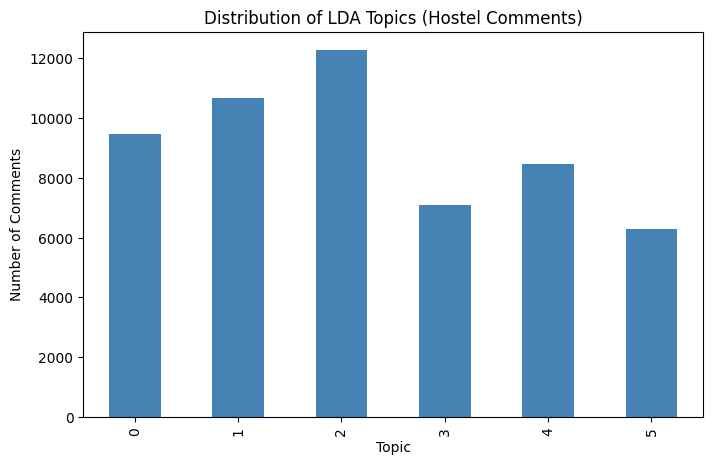

In [51]:
def dominant_topic(bow):
    topics = lda_model.get_document_topics(bow)
    if not topics:
        return -1
    return max(topics, key=lambda x: x[1])[0]

df_lda = df_lda.copy()
df_lda["Topic"] = [dominant_topic(doc) for doc in corpus]

topic_counts = df_lda["Topic"].value_counts().sort_index()

plt.figure(figsize=(8,5))

topic_counts.plot(kind="bar", color="steelblue")

plt.xlabel("Topic")
plt.ylabel("Number of Comments")
plt.title("Distribution of LDA Topics (Hostel Comments)")

plt.savefig("figures/21_distribution_of_lda_topics_hostel_comments.png", dpi=150, bbox_inches="tight")
plt.show()

## University-wise Analysis

#### University-wise Number of Comments

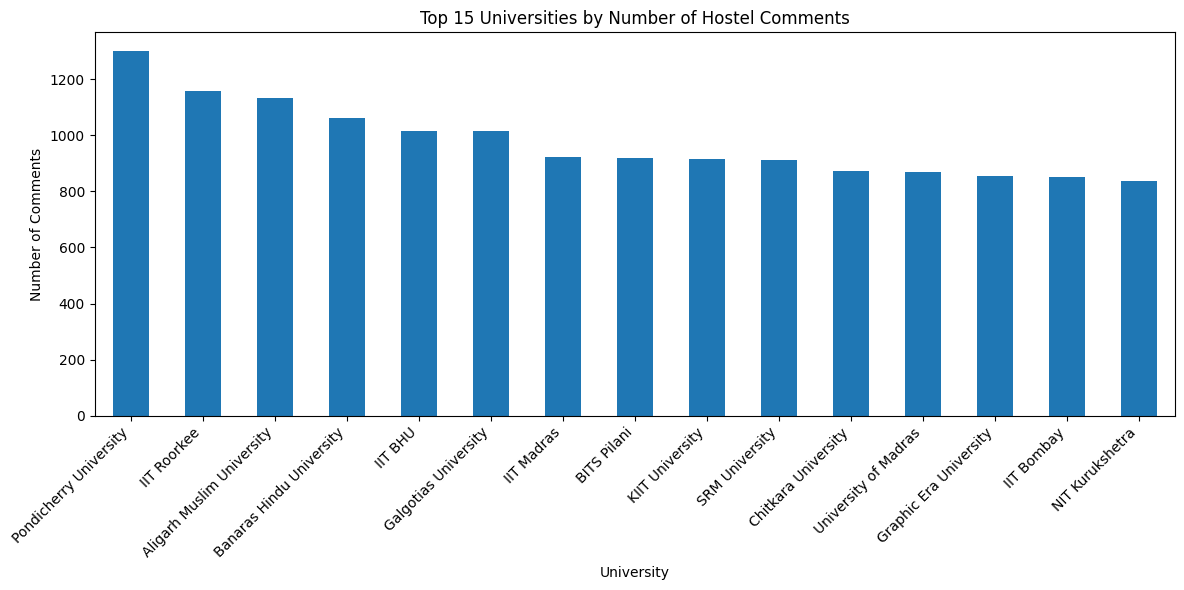

In [52]:
top15 = df["university_name"].value_counts().head(15)

plt.figure(figsize=(12,6))

top15.plot(kind="bar")

plt.xlabel("University")
plt.ylabel("Number of Comments")
plt.title("Top 15 Universities by Number of Hostel Comments")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/22_top_15_universities_by_number_of_hostel_comments.png", dpi=150, bbox_inches="tight")
plt.show()

#### University-wise Questions Asked

High question volume signals genuine confusion or curiosity about hostel life (room allotment, mess quality, curfew rules, safety) that a university's admissions/hostel office could address proactively — e.g. with a hostel FAQ video.

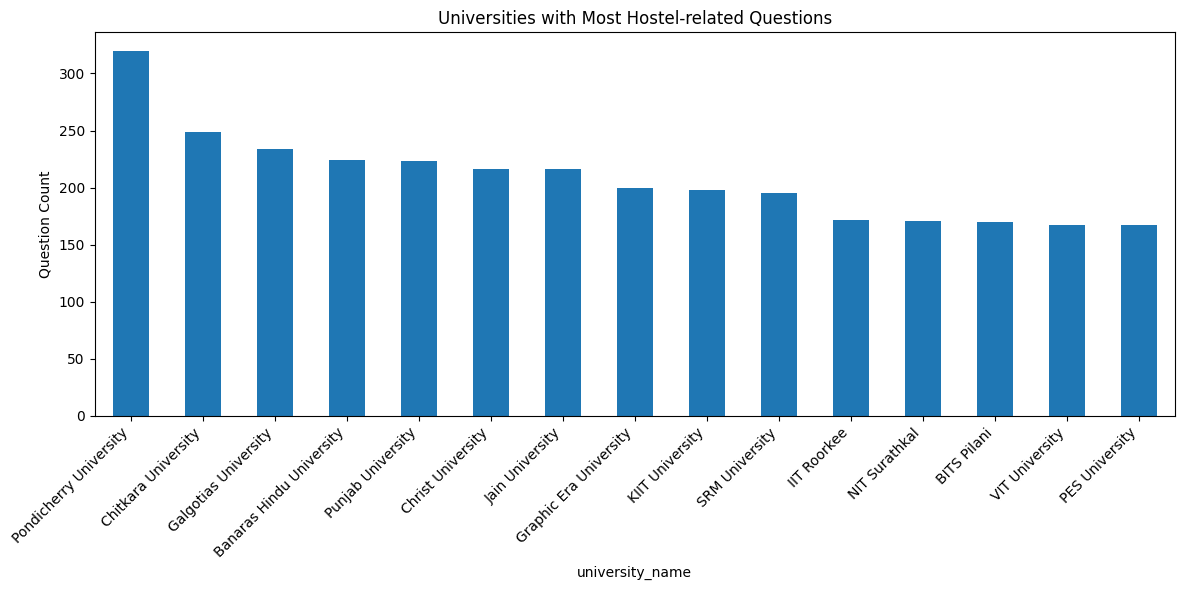

In [53]:
questions = (

    df.groupby("university_name")["contains_question"]

    .sum()

    .sort_values(ascending=False)

    .head(15)

)

questions.plot(kind="bar", figsize=(12,6))

plt.title("Universities with Most Hostel-related Questions")
plt.ylabel("Question Count")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/23_universities_with_most_hostel_related_questions.png", dpi=150, bbox_inches="tight")
plt.show()

### Trend Analysis

#### Monthly Comment Trend

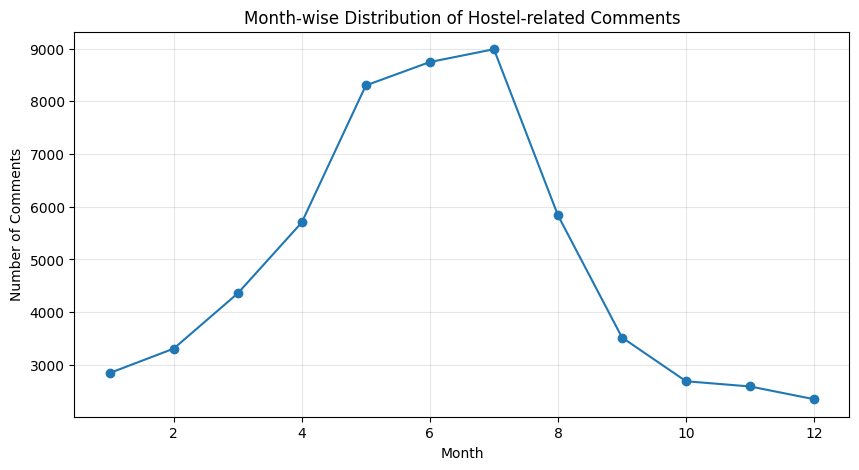

In [54]:
monthly_comments = df.groupby("comment_month").size().sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_comments.index,
    monthly_comments.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Comments")
plt.title("Month-wise Distribution of Hostel-related Comments")

plt.grid(alpha=0.3)
plt.savefig("figures/24_month_wise_distribution_of_hostel_related_comments.png", dpi=150, bbox_inches="tight")
plt.show()

#### Year-wise Trend

Hostel discussions typically spike around admission season (May-August) as newly admitted students look for room-tour content and ask about roommates, mess, and rules before joining.

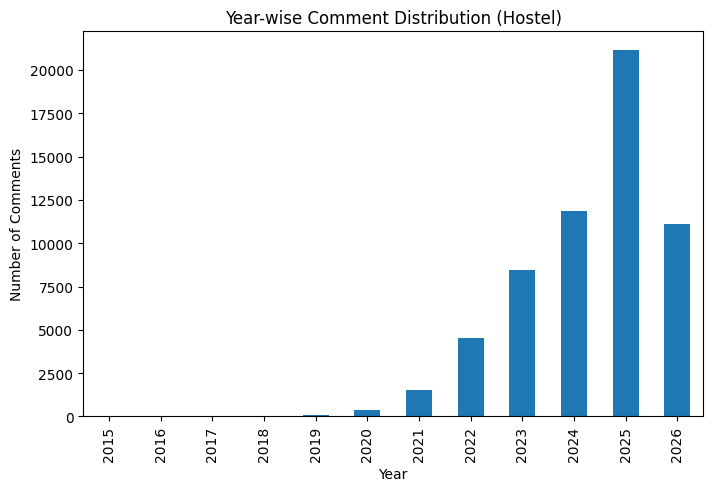

In [55]:
yearly = df.groupby("comment_year").size()

yearly.plot(kind="bar", figsize=(8,5))

plt.title("Year-wise Comment Distribution (Hostel)")
plt.xlabel("Year")
plt.ylabel("Number of Comments")

plt.savefig("figures/25_year_wise_comment_distribution_hostel.png", dpi=150, bbox_inches="tight")
plt.show()

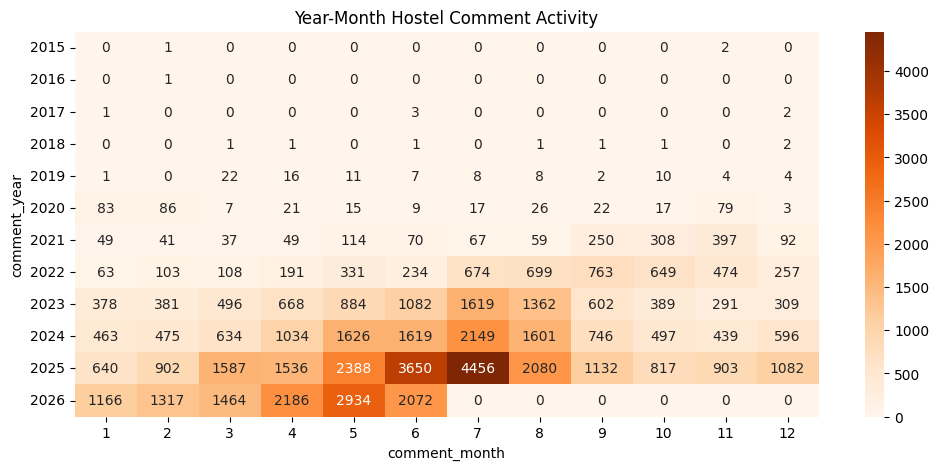

In [56]:
pivot = pd.pivot_table(
    df,
    index="comment_year",
    columns="comment_month",
    values="comment_id",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(12,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Year-Month Hostel Comment Activity")

plt.savefig("figures/26_year_month_hostel_comment_activity.png", dpi=150, bbox_inches="tight")
plt.show()

## Video-Level Analysis (india_universities_hostel_videos.csv)

In [57]:
video_df = pd.read_csv("india_universities_hostel_videos.csv")

video_df.head()

,university_name,category,keyword,video_id,video_title,channel_name,published_at
0,IIT Delhi,hostel,hostel review,nwAvNZkUu6g,IIT Delhi Hostel TOUR - New Hostel with Proper...,Campus Safari,2024-10-19T13:30:28Z
1,IIT Delhi,hostel,hostel review,-Dzh4xYbjGo,IIT Delhi’ best hostel Saptagiri || Complete t...,Vaibhav Chaudhary 183K views . 3 hours ago,2023-06-04T14:55:20Z
2,IIT Delhi,hostel,hostel review,Bl3KqDuF0kI,Full IIT Hostel Tour 🤯| Are they really worth ...,Bhavay Deshwal [IIT-DELHI],2025-07-18T10:45:20Z
3,IIT Delhi,hostel,hostel review,8M-oBUJOQww,Day 2 || Part-2 || #iit DELHI || room tour / h...,Arpit Patel [IIT DELHI],2025-08-01T18:41:54Z
4,IIT Delhi,hostel,hostel review,QsfEuc7Vs-k,IIT Delhi CAMPUS TOUR !! Hostel | Sports | Vlo...,Vinit Kumar [ IIT BOMBAY ],2025-06-07T12:30:26Z


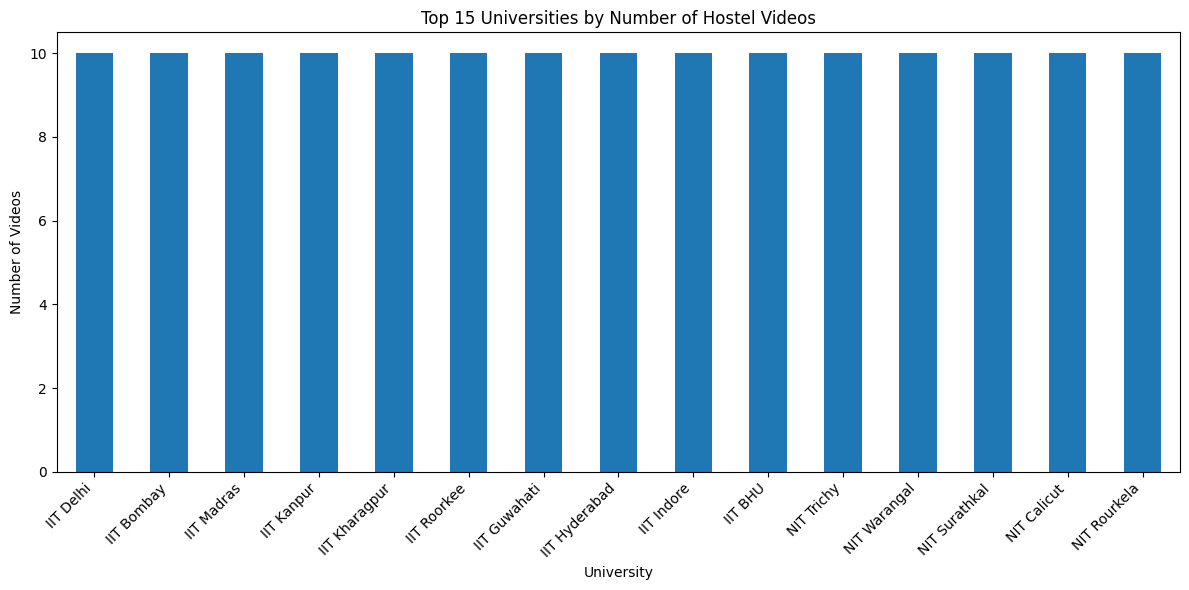

In [58]:
top_videos = video_df["university_name"].value_counts().head(15)

plt.figure(figsize=(12,6))

top_videos.plot(kind="bar")

plt.title("Top 15 Universities by Number of Hostel Videos")
plt.xlabel("University")
plt.ylabel("Number of Videos")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/27_top_15_universities_by_number_of_hostel_videos.png", dpi=150, bbox_inches="tight")
plt.show()

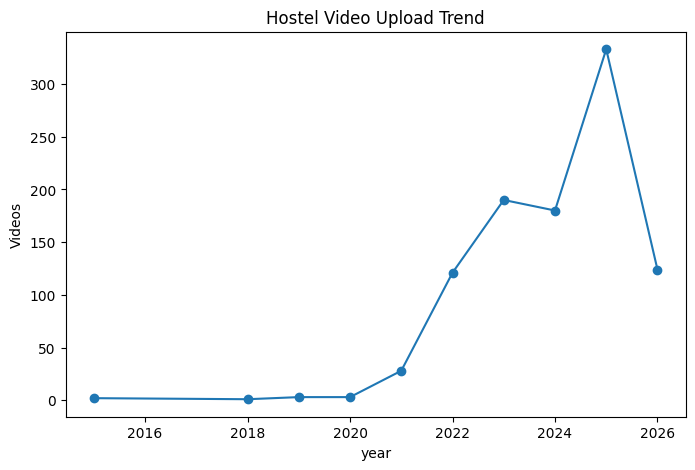

In [59]:
video_df["published_at"] = pd.to_datetime(video_df["published_at"], errors="coerce")
video_df["year"] = video_df["published_at"].dt.year

video_df.groupby("year").size().plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Hostel Video Upload Trend")
plt.ylabel("Videos")

plt.savefig("figures/28_hostel_video_upload_trend.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_484/552093438.py:9: UserWarning: Glyph 3108 (\N{TELUGU LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_484/552093438.py:9: UserWarning: Matplotlib currently does not support Telugu natively.
  plt.tight_layout()
/tmp/ipykernel_484/552093438.py:9: UserWarning: Glyph 3142 (\N{TELUGU VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_484/552093438.py:9: UserWarning: Glyph 3122 (\N{TELUGU LETTER LA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_484/552093438.py:9: UserWarning: Glyph 3137 (\N{TELUGU VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_484/552093438.py:9: UserWarning: Glyph 3095 (\N{TELUGU LETTER GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_484/552093438.py:10: UserWarning: Glyph 3108 (\N{TELUGU LETTER TA}) missing from font(s) DejaVu Sans.
  plt.savefig("figures/29_most_active_youtube_channels_covering_host

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3108 (\N{TELUGU LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Matplotlib currently does not support Telugu natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3142 (\N{TELUGU VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3122 (\N{TELUGU LETTER LA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3137 (\N{TELUGU VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-p

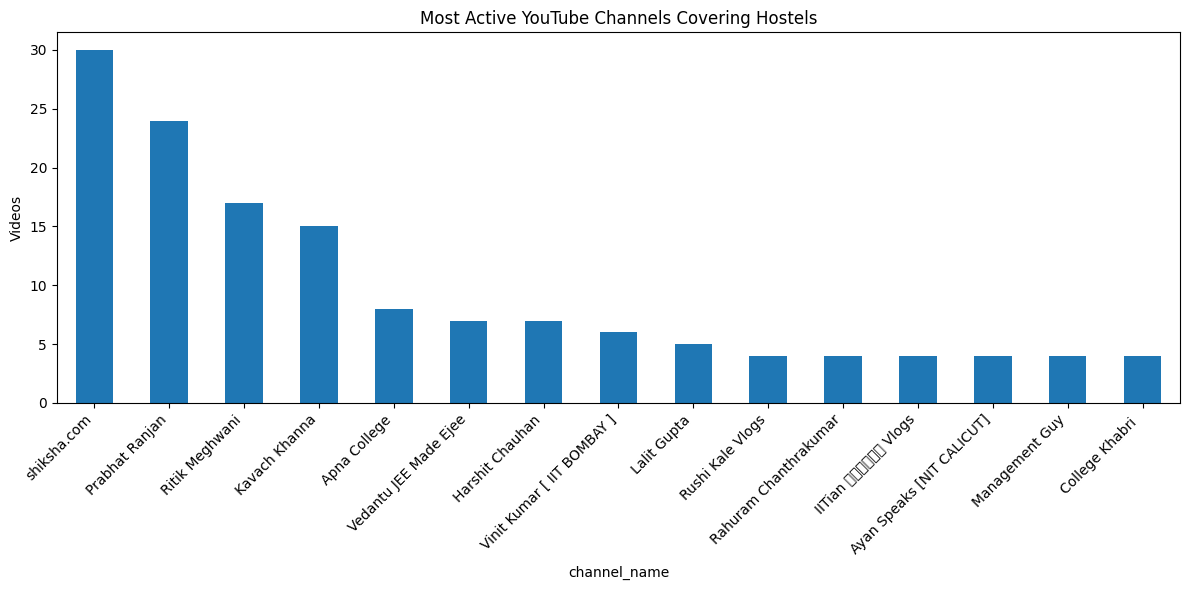

In [60]:
top_channel = video_df["channel_name"].value_counts().head(15)

top_channel.plot(kind="bar", figsize=(12,6))

plt.title("Most Active YouTube Channels Covering Hostels")
plt.ylabel("Videos")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/29_most_active_youtube_channels_covering_hostels.png", dpi=150, bbox_inches="tight")
plt.show()

In [61]:
# Cross-check: which universities have LOTS of comments but FEW videos?
# -> Indicates high organic demand for hostel information relative to available content.

comments_per_uni = df["university_name"].value_counts()
videos_per_uni = video_df["university_name"].value_counts()

demand_gap = pd.DataFrame({
    "comments": comments_per_uni,
    "videos": videos_per_uni
}).fillna(0)

demand_gap["comments_per_video"] = (
    demand_gap["comments"] / demand_gap["videos"].replace(0, 1)
)

demand_gap.sort_values("comments_per_video", ascending=False).head(15)

,comments,videos,comments_per_video
university_name,,,
Pondicherry University,1302.0,10,130.2
IIT Roorkee,1158.0,10,115.8
Aligarh Muslim University,1132.0,10,113.2
Banaras Hindu University,1060.0,10,106.0
IIT BHU,1015.0,10,101.5
Galgotias University,1014.0,10,101.4
IIT Madras,924.0,10,92.4
BITS Pilani,919.0,10,91.9
KIIT University,915.0,10,91.5


### Interpretation

Universities with a high **comments-per-video** ratio (Pondicherry University, IIT Roorkee, Aligarh Muslim University, Banaras Hindu University) are ones where a fixed, small set of videos (10 each, since the source data was collected uniformly per university) is absorbing a disproportionate amount of audience curiosity about hostel life — strong candidates for more dedicated hostel-tour or hostel-FAQ content.

#### Video-Type Classification

Classifying each video's title into a rough type (Tour, Review/Comparison, Vlog/Day-in-life, Fee/Cost Info, Other) using keyword rules shows what kind of hostel content actually exists on YouTube versus what commenters ask about.

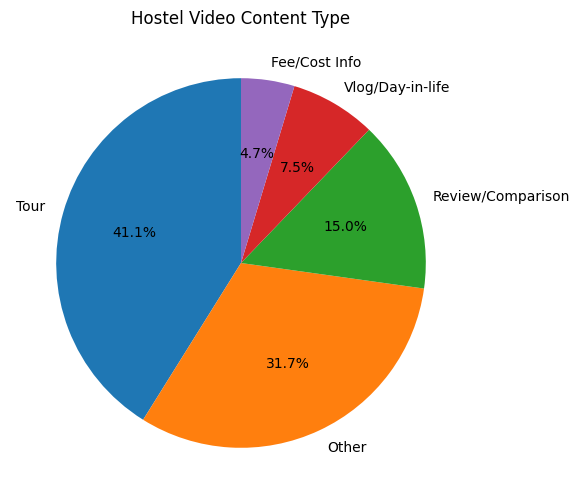

In [62]:
def classify_video_type(title):
    t = str(title).lower()
    if any(k in t for k in ["tour", "walkthrough", "inside"]):
        return "Tour"
    elif any(k in t for k in ["review", "worth it", "vs", "comparison", "compare"]):
        return "Review/Comparison"
    elif any(k in t for k in ["vlog", "day in", "life in", "life at"]):
        return "Vlog/Day-in-life"
    elif any(k in t for k in ["fee", "fees", "cost", "rent"]):
        return "Fee/Cost Info"
    else:
        return "Other"

video_df["video_type"] = video_df["video_title"].apply(classify_video_type)

video_type_counts = video_df["video_type"].value_counts()

plt.figure(figsize=(8,6))

plt.pie(
    video_type_counts,
    labels=video_type_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Hostel Video Content Type")

plt.savefig("figures/30_hostel_video_content_type.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

**Room/facility "Tours"** make up the largest share of hostel videos (~41%), which lines up with the top TF/TF-IDF words (room, single, campus) — creators default to a walkthrough format. **Review/Comparison** videos are the second-biggest category, but dedicated **Fee/Cost Info** videos are rare (under 5%) even though Fee/Rent is one of the top two hostel-concern categories in the comments — a clear content gap between what creators upload and what commenters actually want to know.

## Overall Findings

1. **Volume & length**: Hostel comments are mostly short reactions; longer comments cluster around detailed room/mess descriptions and rule complaints. Mean length (~60 chars) sits notably above the median (40 chars), confirming a right-skewed distribution.
2. **Dominant vocabulary**: TF, TF-IDF, and the word cloud consistently surface *room, mess, single, fees, girls/boys, campus* as the core vocabulary — but hostel-tour comment sections are also heavily used for general admission chatter (JEE, CSE, branch, placements).
3. **Rent/fee-amount extraction** (new): only ~2% of comments quote a specific figure, but where they do, private universities cluster at the high end (₹1.5-3L/year) versus lower figures at government IITs/NITs.
4. **Concern categorization** (new): Fee/Rent and Room Quality/Infrastructure are the leading hostel-specific concerns; Mess/Food is the smallest of the major buckets by volume but by far the most negative (~46% negative) — the single clearest pain point.
5. **Amenity-level analysis** (new): Mess/Food is both the most-mentioned amenity and the most negatively rated; Security is mentioned less often but skews positive, with a real but smaller negative tail.
6. **Engagement**: IIT Bombay and FLAME University post the highest average likes/engagement scores per hostel comment, well above the rest of the field.
7. **Trend**: Hostel discussions peak in the May-July window, aligning with the admission decision season, and comment volume has grown sharply year-over-year through 2025.
8. **Demand gap & content gap** (new): Some universities receive very heavy comment volume relative to their available hostel videos. At the content-type level, dedicated "Tour" videos dominate uploads while Fee/Cost-specific videos are rare — even though Fee/Rent is a top-2 comment concern, suggesting an under-served content niche for creators.